Saved: motivation_chart.mp4


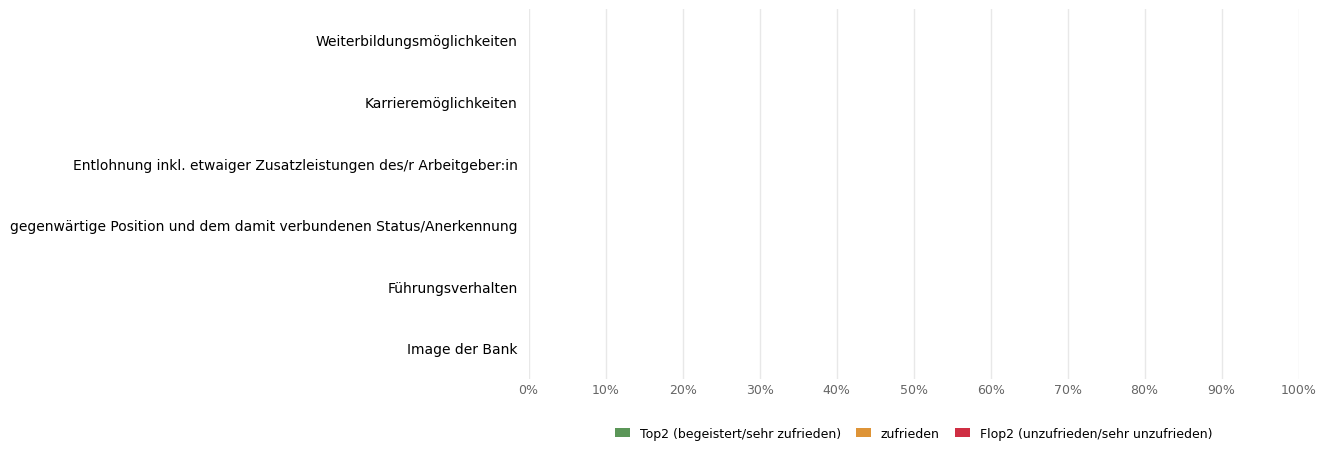

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.animation import FuncAnimation, FFMpegWriter
from matplotlib.patches import Patch
from IPython.display import HTML

# -----------------------------
# CONFIG
# -----------------------------
fps = 30
total_duration_sec = 12
pause_duration_sec = 3

total_frames = int(fps * total_duration_sec)
pause_frames = int(fps * pause_duration_sec)
total_frames_with_pause = total_frames + pause_frames

label_fontsize = 10
label_padding_data = 1.2   # extra room inside bar, in percentage-point units

# -----------------------------
# DATA: Motivation only
# columns = [Top2, zufrieden, Flop2]
# -----------------------------
categories = [
    "Weiterbildungsmöglichkeiten",
    "Karrieremöglichkeiten",
    "Entlohnung inkl. etwaiger Zusatzleistungen des/r Arbeitgeber:in",
    "gegenwärtige Position und dem damit verbundenen Status/Anerkennung",
    "Führungsverhalten",
    "Image der Bank"
]

data = np.array([
    [51.6, 36.6, 11.8],
    [40.0, 47.2, 12.8],
    [22.8, 53.7, 23.5],
    [58.5, 33.5,  8.0],
    [60.8, 32.9,  6.3],
    [70.8, 28.7,  0.5]
])

colors = ["#5b9658", "#de9437", "#cf2e43"]
legend_labels = [
    "Top2 (begeistert/sehr zufrieden)",
    "zufrieden",
    "Flop2 (unzufrieden/sehr unzufrieden)"
]

n_rows, n_cols = data.shape
proportions = data / 100.0

# -----------------------------
# HELPERS
# -----------------------------
def fmt_percent(v):
    """German formatting: 40% / 36,6% / 0,5%"""
    if abs(v - round(v)) < 1e-9:
        return f"{int(round(v))}%"
    return f"{v:.1f}%".replace(".", ",")

def text_width_in_data(ax, fig, text, fontsize=10, fontweight="bold"):
    """
    Measure text width and convert it to x-data units.
    """
    temp = ax.text(
        0, 0, text,
        fontsize=fontsize,
        fontweight=fontweight,
        alpha=0
    )
    fig.canvas.draw()
    bbox = temp.get_window_extent(renderer=fig.canvas.get_renderer())
    temp.remove()

    data_range = ax.get_xlim()[1] - ax.get_xlim()[0]
    axes_width_px = ax.bbox.width
    return bbox.width * (data_range / axes_width_px)

# -----------------------------
# FIGURE
# -----------------------------
fig, ax = plt.subplots(figsize=(14, 4.8))
plt.subplots_adjust(left=0.43, right=0.98, top=0.97, bottom=0.20)

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.set_xlim(0, 100)
ax.set_ylim(-0.5, n_rows - 0.5)
ax.set_yticks(range(n_rows))
ax.set_yticklabels(categories, fontsize=10)
ax.invert_yaxis()

ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
ax.tick_params(axis="x", length=0, labelsize=9, colors="#666666")
ax.tick_params(axis="y", length=0, pad=8)

ax.grid(True, axis="x", linestyle="-", linewidth=1, alpha=0.18, color="#808080")
for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

# -----------------------------
# BARS
# -----------------------------
bars = []
for j in range(n_cols):
    bc = ax.barh(
        range(n_rows),
        np.zeros(n_rows),
        left=np.zeros(n_rows),
        height=0.62,
        color=colors[j],
        edgecolor="none"
    )
    bars.append(bc)

# -----------------------------
# TEXTS
# -----------------------------
texts = []
for j in range(n_cols):
    row_texts = []
    for i in range(n_rows):
        t = ax.text(
            0, i, "",
            ha="center", va="center",
            fontsize=label_fontsize,
            fontweight="bold",
            color="white",
            alpha=0,
            clip_on=True
        )
        row_texts.append(t)
    texts.append(row_texts)

# Precompute stable "fit" thresholds from FINAL labels
fit_thresholds = np.zeros_like(data)
for i in range(n_rows):
    for j in range(n_cols):
        final_label = fmt_percent(data[i, j])
        fit_thresholds[i, j] = text_width_in_data(
            ax, fig, final_label,
            fontsize=label_fontsize,
            fontweight="bold"
        ) + label_padding_data

# -----------------------------
# LEGEND
# -----------------------------
handles = [Patch(facecolor=c, edgecolor="none", label=l) for c, l in zip(colors, legend_labels)]
ax.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=3,
    frameon=False,
    fontsize=9,
    handlelength=1.2,
    columnspacing=1.2
)

# -----------------------------
# ANIMATION
# -----------------------------
def animate(frame):
    effective_frame = min(frame, total_frames - 1)
    progress = effective_frame / (total_frames - 1)

    artists = []

    for i in range(n_rows):
        cum_left = 0.0
        cum_share = 0.0

        for j in range(n_cols):
            seg_share = proportions[i, j]
            seg_final_width = data[i, j]

            start = cum_share
            end = cum_share + seg_share

            # sequential stacked growth
            if progress <= start:
                current_share = 0.0
            elif progress >= end:
                current_share = seg_share
            else:
                current_share = progress - start

            current_width = current_share * 100.0

            rect = bars[j][i]
            rect.set_x(cum_left)
            rect.set_width(current_width)
            artists.append(rect)

            txt = texts[j][i]

            if seg_share > 0:
                current_value = seg_final_width * (current_share / seg_share)
            else:
                current_value = 0.0

            # Reveal as soon as the label can fit, then keep updating
            if current_width >= fit_thresholds[i, j]:
                txt.set_text(fmt_percent(current_value))
                txt.set_position((cum_left + current_width / 2.0, i))
                txt.set_alpha(1)
            else:
                txt.set_alpha(0)

            artists.append(txt)

            cum_left += current_width
            cum_share = end

    return artists

anim = FuncAnimation(
    fig,
    animate,
    frames=total_frames_with_pause,
    interval=1000 / fps,
    blit=False,
    repeat=False
)

# -----------------------------
# SAVE
# -----------------------------
writer = FFMpegWriter(
    fps=fps,
    codec="libx264",
    bitrate=2500,
    extra_args=["-pix_fmt", "yuv420p"]
)
anim.save("motivation_chart.mp4", writer=writer, dpi=300)
print("Saved: motivation_chart.mp4")

HTML(anim.to_html5_video())

In [6]:
from google.colab import files
files.download('motivation_chart.mp4')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# !ffmpeg -stream_loop 1 -i arbeitsumfeld_stacked_anim_final.mp4 -c copy arbeitsumfeld.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab